# Penguin Species Prediction — Kaggle Palmer Penguins Dataset

**Project flavor:** Predict / tabular machine learning  
**Goal:** Train a model that predicts a penguin's species from physical measurements.  
**Team output:** A runnable Colab notebook, a short write-up, and a 5-minute presentation for 3 people.

This notebook is written as a beginner-friendly project document. Every code cell has a short explanation immediately above it so the team can understand, present, and defend each step.

## 1. Setup: install and import the required libraries

This cell installs `kagglehub` so Colab can download the public Kaggle Palmer Penguins dataset without manually uploading files. Then it imports the main Python libraries for data handling, visualization, model training, and evaluation.

In [1]:
# Install KaggleHub if it is not already available in Colab
try:
    import kagglehub
except ImportError:
    !pip -q install kagglehub
    import kagglehub

# Core data and plotting libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

# Make plots easier to read
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load the Kaggle dataset

The Kaggle dataset usually contains two files. For a beginner prediction project, `penguins_size.csv` is the best choice because it is already simplified and contains the key biological measurements. The code downloads the dataset and automatically finds the CSV file.

In [2]:
# Download the public Kaggle dataset
# Dataset page: parulpandey/palmer-archipelago-antarctica-penguin-data
path = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")
print("Dataset downloaded to:", path)

# Find the simplified CSV file
csv_files = list(Path(path).rglob("*.csv"))
print("CSV files found:", [f.name for f in csv_files])

# Prefer the simplified file; fall back to the first CSV if needed
csv_path = None
for file in csv_files:
    if "penguins_size" in file.name.lower():
        csv_path = file
        break
if csv_path is None:
    csv_path = csv_files[0]

print("Using file:", csv_path.name)
df = pd.read_csv(csv_path)
df.head()


Dataset downloaded to: /kaggle/input/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data
CSV files found: ['penguins_size.csv', 'penguins_lter.csv']
Using file: penguins_size.csv


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 3. Understand the dataset shape and columns

Before building a model, we inspect the number of rows, columns, data types, and basic summary statistics. This helps us understand what information is available and whether the target column is suitable for classification.

In [4]:
print("Rows and columns:", df.shape)
print("Column names:")
print(df.columns.tolist())

print("Data types:")
print(df.dtypes)

print("Summary statistics:")
df.describe(include='all')


Rows and columns: (344, 7)
Column names:
['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Data types:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
Summary statistics:


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


## 4. Standardize column names

Some versions of the Palmer Penguins dataset use `culmen_length_mm` and `culmen_depth_mm`, while others use `bill_length_mm` and `bill_depth_mm`. They refer to the same biological measurements. This cell renames the columns so our later code is easier to read.

In [5]:
df = df.rename(columns={
    'culmen_length_mm': 'bill_length_mm',
    'culmen_depth_mm': 'bill_depth_mm'
})

print(df.columns.tolist())
df.head()

['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 5. Check missing and unusual values

Real datasets are often slightly messy. In this dataset, some values are missing, and the `sex` column may contain a `.` symbol that actually means unknown. We count missing values and inspect categorical values before cleaning.

In [7]:
print("Missing values before cleaning:")
print(df.isna().sum())

for col in ['species', 'island', 'sex']:
    if col in df.columns:
        print(f"Unique values in {col}:")
        print(df[col].value_counts(dropna=False))

Missing values before cleaning:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64
Unique values in species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
Unique values in island:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
Unique values in sex:
sex
MALE      168
FEMALE    165
NaN        10
.           1
Name: count, dtype: int64


## 6. Clean the data

For this beginner project, we use a simple cleaning strategy: replace `.` with missing, then drop rows with missing values in important columns. This keeps the workflow easy to explain and avoids training on incomplete examples.

In [9]:
# Replace the unusual '.' value with proper missing value
if 'sex' in df.columns:
    df['sex'] = df['sex'].replace('.', np.nan)

# Keep only the columns we need for predicting species
needed_columns = ['species', 'island', 'bill_length_mm', 'bill_depth_mm',
                  'flipper_length_mm', 'body_mass_g', 'sex']
needed_columns = [c for c in needed_columns if c in df.columns]

df_clean = df[needed_columns].dropna().copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Missing values after cleaning:")
print(df_clean.isna().sum())

df_clean.head()

Original shape: (344, 7)
Cleaned shape: (333, 7)
Missing values after cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


## 7. Explore the target variable

The target is `species`. A good classification project should check whether the classes are balanced or highly imbalanced. If one species had many more rows than the others, accuracy alone could become misleading.

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


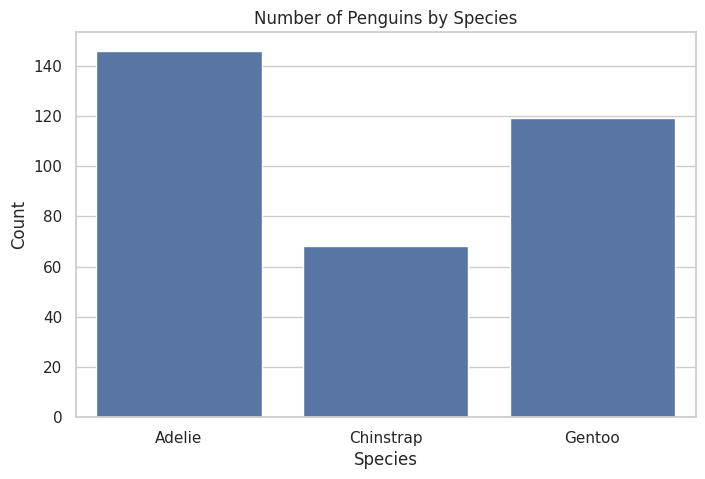

In [10]:
species_counts = df_clean['species'].value_counts()
print(species_counts)

sns.countplot(data=df_clean, x='species')
plt.title('Number of Penguins by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

## 8. Explore feature patterns visually

This plot compares bill length and bill depth across species. If the species form visible groups, a machine-learning model may be able to learn useful boundaries from the measurements.

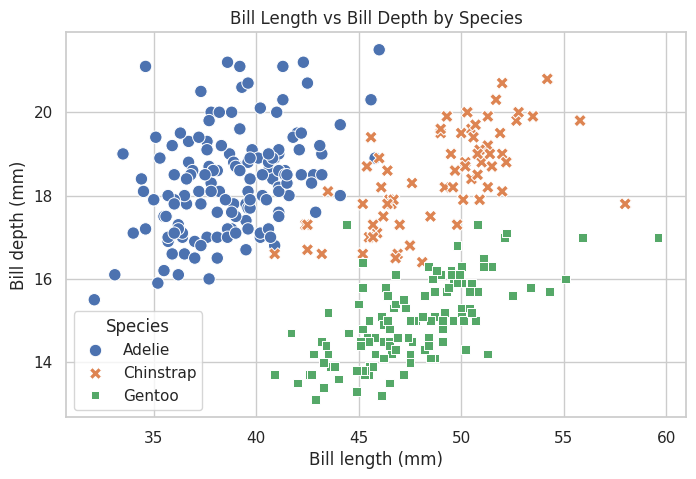

In [11]:
sns.scatterplot(
    data=df_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    style='species',
    s=80
)
plt.title('Bill Length vs Bill Depth by Species')
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)')
plt.legend(title='Species')
plt.show()

## 9. Define features and target

`X` contains the input features used for prediction. `y` contains the correct species labels. We keep both numerical measurements and categorical information such as island and sex.

In [12]:
X = df_clean.drop(columns=['species'])
y = df_clean['species']

print("Feature columns:", X.columns.tolist())
print("Target classes:", sorted(y.unique()))
X.head()

Feature columns: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Target classes: ['Adelie', 'Chinstrap', 'Gentoo']


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Torgersen,39.3,20.6,190.0,3650.0,MALE


## 10. Split the data into training and test sets

The model learns from the training set and is evaluated on the test set. We use a stratified split so that each species is represented fairly in both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Training class distribution:")
print(y_train.value_counts(normalize=True))
print("Test class distribution:")
print(y_test.value_counts(normalize=True))

Training rows: 249
Test rows: 84
Training class distribution:
species
Adelie       0.437751
Gentoo       0.357430
Chinstrap    0.204819
Name: proportion, dtype: float64
Test class distribution:
species
Adelie       0.440476
Gentoo       0.357143
Chinstrap    0.202381
Name: proportion, dtype: float64


## 11. Build a preprocessing pipeline

Machine-learning models need numerical input. Numerical features are scaled, while categorical features are converted into one-hot encoded columns. Putting preprocessing inside a pipeline helps prevent mistakes and keeps the workflow reproducible.

In [15]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features: ['island', 'sex']


## 12. Train Model 1: Random Forest

A Random Forest is a strong beginner-friendly model because it handles non-linear patterns well and often performs strongly on tabular data. It also gives useful feature-importance information.

In [16]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest accuracy:", round(rf_accuracy, 4))
print("Classification report:")
print(classification_report(y_test, rf_preds))

Random Forest accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        37
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        30

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



## 13. Train Model 2: Logistic Regression

For the stretch goal, we compare Random Forest with a second model. Logistic Regression is simpler and easier to explain. Comparing both helps us decide whether the more complex model is actually needed.

In [17]:
log_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_preds)
print("Logistic Regression accuracy:", round(log_accuracy, 4))
print("Classification report:")
print(classification_report(y_test, log_preds))

Logistic Regression accuracy: 0.9881
Classification report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.99        37
   Chinstrap       0.94      1.00      0.97        17
      Gentoo       1.00      1.00      1.00        30

    accuracy                           0.99        84
   macro avg       0.98      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84



## 14. Compare the two models

This small table makes the result presentation easier. For the 5-minute talk, one clear number is enough: which model performed better on the held-out test set?

In [18]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Test Accuracy': [rf_accuracy, log_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)

results

,Model,Test Accuracy
0,Random Forest,1.000000
1,Logistic Regression,0.988095


## 15. Show the confusion matrix for the best model

A confusion matrix shows which species were predicted correctly and which were confused with another species. This is more informative than accuracy alone because it reveals the type of mistakes the model makes.

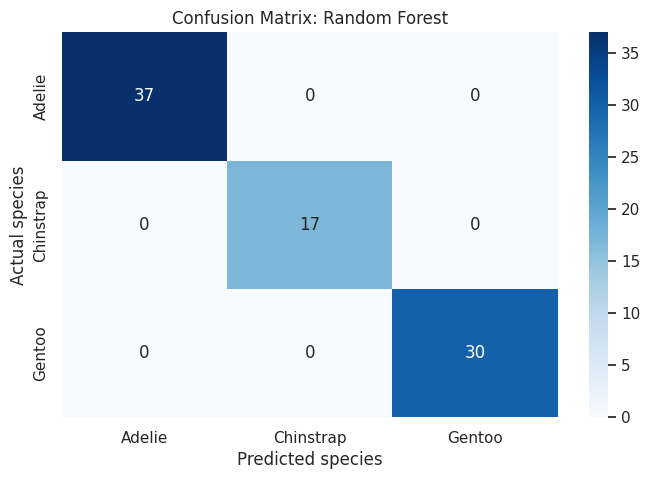

In [19]:
best_model = rf_model if rf_accuracy >= log_accuracy else log_model
best_name = 'Random Forest' if rf_accuracy >= log_accuracy else 'Logistic Regression'
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix: {best_name}')
plt.xlabel('Predicted species')
plt.ylabel('Actual species')
plt.show()

## 16. Explain which features mattered most

Feature importance helps answer the question: *what did the model rely on?* We use permutation importance because it works with the full pipeline and measures how much model performance drops when each feature is shuffled.

             Feature  Importance       Std
0             island    0.235714  0.029786
3  flipper_length_mm    0.230357  0.033307
1     bill_length_mm    0.191667  0.033013
2      bill_depth_mm    0.019643  0.006813
4        body_mass_g    0.000000  0.000000
5                sex    0.000000  0.000000


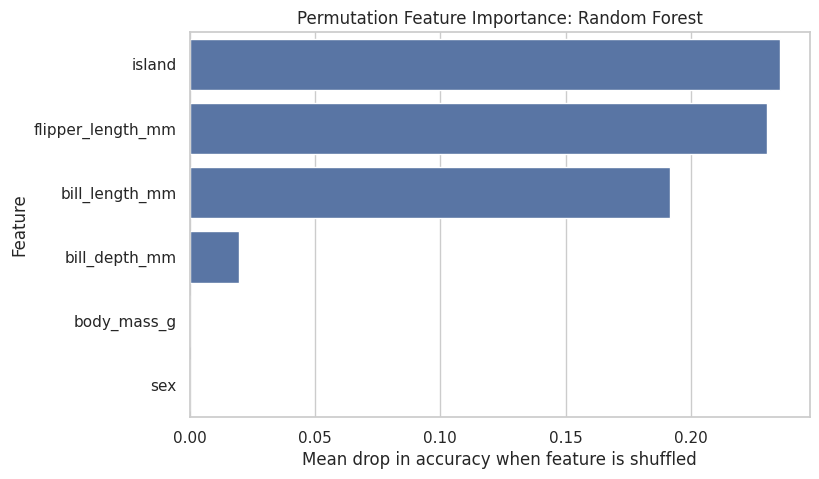

In [20]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring='accuracy'
)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values(by='Importance', ascending=False)

print(importance_df)

sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title(f'Permutation Feature Importance: {best_name}')
plt.xlabel('Mean drop in accuracy when feature is shuffled')
plt.ylabel('Feature')
plt.show()

## 17. Try a single prediction

This small example demonstrates how the trained model could be used on a new penguin. In a real system, the values would come from a new measurement record.

In [21]:
example_penguin = pd.DataFrame([{
    'island': 'Biscoe',
    'bill_length_mm': 45.0,
    'bill_depth_mm': 14.5,
    'flipper_length_mm': 215.0,
    'body_mass_g': 5000.0,
    'sex': 'MALE'
}])

# Match the exact column order used during training
example_penguin = example_penguin[X.columns]

prediction = best_model.predict(example_penguin)[0]
probabilities = pd.Series(best_model.predict_proba(example_penguin)[0], index=best_model.classes_)

print("Predicted species:", prediction)
print("Prediction probabilities:")
print(probabilities.sort_values(ascending=False))

Predicted species: Gentoo
Prediction probabilities:
Gentoo       1.0
Adelie       0.0
Chinstrap    0.0
dtype: float64


## 18. Real-world risks and limitations

This model is useful for learning, but it should not be treated as a perfect real-world wildlife system. Possible issues include small dataset size, missing values, measurement errors, limited geographic coverage, and changes in penguin populations over time. A real deployment would need more data, expert review, and continuous monitoring.

## 19. Suggested team prompts to save in the write-up

1. **Context + role:** “I am a beginner working in Google Colab with a cleaned Palmer Penguins dataframe. Act as a patient data-science tutor and explain why stratified train-test splitting is useful.”
2. **Debugging:** “This Colab cell gave me the following error. Explain the error in simple words and suggest the smallest fix without rewriting the whole notebook.”
3. **Interpretation:** “Explain this confusion matrix and feature-importance chart in plain English for a 5-minute student presentation.”